# 2 - Visualization
Overlaying student GPS submissions on top of the physical amphitheater footprint polygons.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import numpy as np
import pandas as pd
import seaborn as sns
import os

## 1. Load Student GPS Data
We load the dataset and reverse the row order (newest-first export).

In [2]:
csv_path = r'C:\Users\ASUS\Desktop\3y\S2\machine learning\Project\Local\Data\ensia_gps_data .csv'
df = pd.read_csv(csv_path)

# Reverse order (export is newest-first)
df = df.iloc[::-1].reset_index(drop=True)

print(f"Loaded {len(df)} submissions.")
df[['amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']].head()

Loaded 8701 submissions.


,amphitheatre,latitude_mean,longitude_mean,is_outside
0,Amphi 6,36.688368,2.866433,False
1,Amphi 6,36.686801,2.865971,False
2,Amphi 6,36.688404,2.866466,False
3,Amphi 5,36.688309,2.866291,False
4,Amphi 6,36.688313,2.866473,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8701 entries, 0 to 8700
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8701 non-null   int64  
 1   year                 8407 non-null   float64
 2   section              0 non-null      float64
 3   user                 1161 non-null   object 
 4   amphitheatre         8701 non-null   object 
 5   module               7834 non-null   object 
 6   seat_block           7152 non-null   object 
 7   seat_row             7152 non-null   float64
 8   seat_column          7152 non-null   float64
 9   latitude_mean        8701 non-null   float64
 10  longitude_mean       8701 non-null   float64
 11  accuracy_mean        8407 non-null   float64
 12  gps_variance         8407 non-null   float64
 13  is_outside           8701 non-null   bool   
 14  sample_count         8701 non-null   int64  
 15  raw_gps_readings     8701 non-null   o

In [4]:
# Standardize amphitheatretheater labels
# Keep amphitheatre 1-8, change everything else to "Outside"
valid_amphis = [f"Amphi {i}" for i in range(1, 9)]  # Amphi 1 through Amphi 8

print("Before standardization:")
print(f"Unique amphitheater labels: {df['amphitheatre'].unique()}")
print(f"Label counts:\n{df['amphitheatre'].value_counts()}")

# Replace non-standard labels with "Outside"
df['amphitheatre'] = df['amphitheatre'].apply(lambda x: x if x in valid_amphis else "Outside")

print("\nAfter standardization:")
print(f"Unique amphitheater labels: {df['amphitheatre'].unique()}")
print(f"Label counts:\n{df['amphitheatre'].value_counts()}")

# Verify we have the expected classes
expected_classes = valid_amphis + ["Outside"]
actual_classes = sorted(df['amphitheatre'].unique())
print(f"\nExpected classes: {expected_classes}")
print(f"Actual classes: {actual_classes}")
print(f"Classes match: {set(expected_classes) == set(actual_classes)}")

Before standardization:
Unique amphitheater labels: ['Amphi 6' 'Amphi 5' 'lkhadra' 'Lab 7 ' 'Amphi 1' 'Amphi 8'
 'In front of amphi 8' 'study room' 'Lab 8' 'Dorms' 'tuto23' 'Hall'
 'AMPHI8' 'Amphi 3' 'Amphi 4' 'Amphi 3 door 1 ' 'Amphi 3 door 2 '
 'Salle d’études' "Salle d'études" 'maalma3' 'Spot ' 'Amphi 2'
 'SkillnTell Spot ' 'Amphi 7' 'Outside' 'Mdpres end tarek' 'Nasro'
 'Hfgnffn' 'nasro ' 'outside' 'dorm' 'mazalni end tarek' 'end tarek'
 'room' 'School entry' 'lab 8']
Label counts:
amphitheatre
Amphi 2                2565
Amphi 5                1359
Amphi 8                 989
Amphi 6                 936
Amphi 4                 741
Outside                 658
Amphi 1                 625
Amphi 3                 318
Amphi 7                 122
Nasro                   100
Mdpres end tarek         46
maalma3                  33
Dorms                    21
SkillnTell Spot          20
Salle d'études           20
lkhadra                  10
Lab 7                    10
tuto23              

## 2. Amphitheater Landmarks (Polygons)
Physical boundaries for the 4 amphitheater spaces.

In [5]:
amphi_corners = {
    "Amphi 1/5": [
        (36.6882320, 2.8666535),  # top-left
        (36.6882443, 2.8668060),  # top-right
        (36.6880865, 2.8668389),  # bottom-right
        (36.6880720, 2.8666538),  # bottom-left
    ],
    "Amphi 2/6": [
        (36.6882129, 2.8663997),  # top-left
        (36.6882193, 2.8665428),  # top-right
        (36.6880268, 2.8665894),  # bottom-right
        (36.6880123, 2.8663926),  # bottom-left
    ],
    "Amphi 3/7": [
        (36.6881935, 2.8661324),  # top-left
        (36.6881954, 2.8662759),  # top-right
        (36.6880368, 2.8663122),  # bottom-right
        (36.6880252, 2.8661318),  # bottom-left
    ],
    "Amphi 4/8": [
        (36.6881693, 2.8658652),  # top-left
        (36.6881817, 2.8660131),  # top-right
        (36.6880179, 2.8660490),  # bottom-right
        (36.6880075, 2.8658649),  # bottom-left
    ],
}

## 3. Analysis Plot
Visualizing submissions on top of physical basins to check for drift and accuracy.

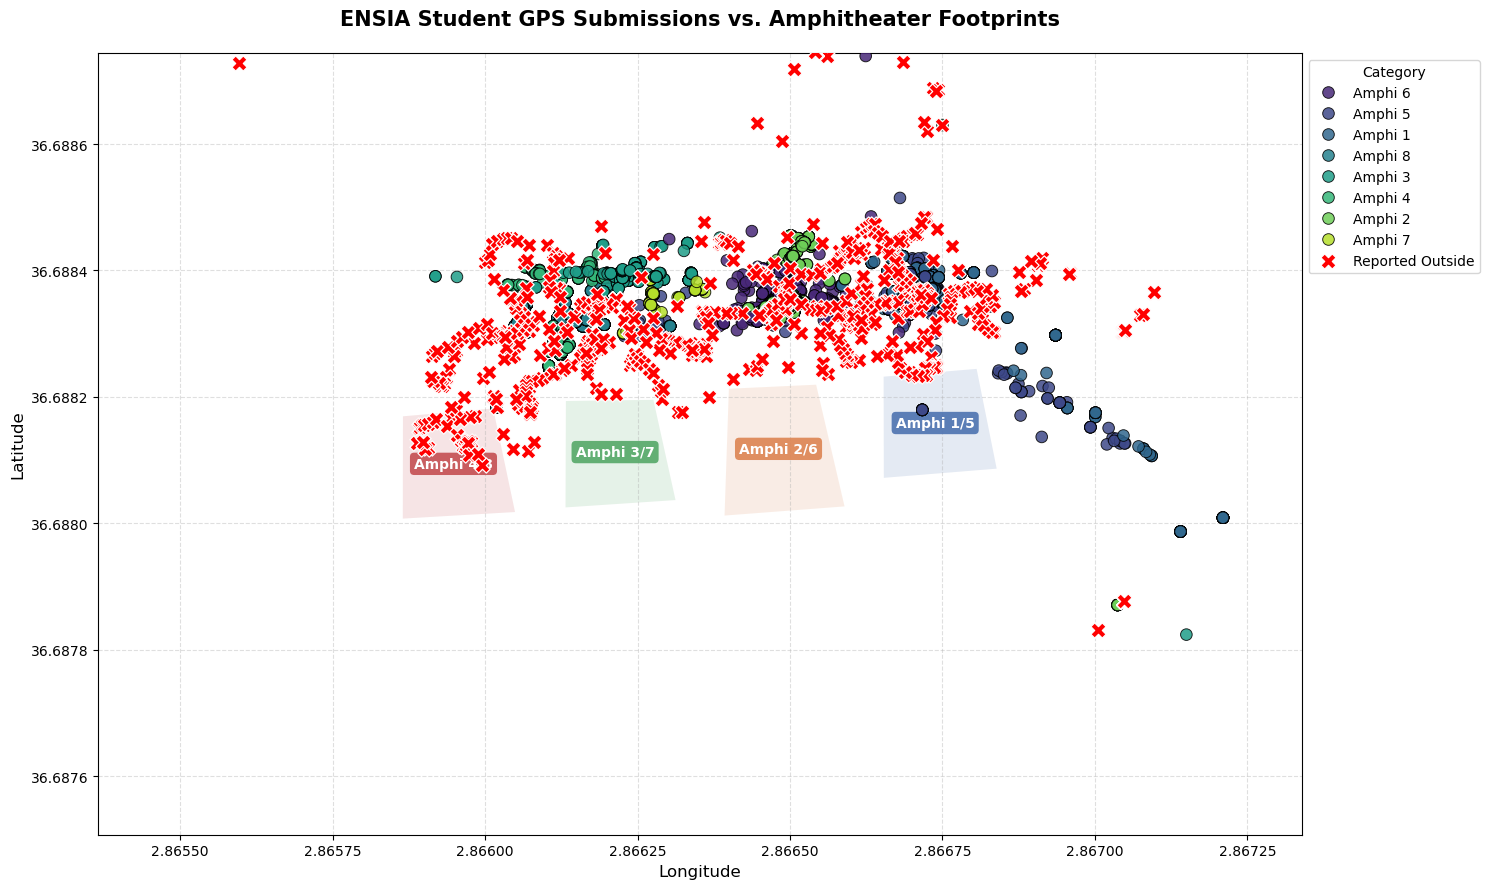

In [6]:
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
amphi_names = list(amphi_corners.keys())

fig, ax = plt.subplots(figsize=(15, 9))

# 1. Plot Polygons (Amphi Areas)
patches = []
for (name, corners), color in zip(amphi_corners.items(), colors):
    # Convert (lat, lon) -> (lon, lat) for (x, y) coordinates
    xy = np.array([(lon, lat) for lat, lon in corners])
    poly = Polygon(xy, closed=True)
    patches.append(poly)

    # Label the amphi at center
    cx, cy = xy[:, 0].mean(), xy[:, 1].mean()
    ax.text(cx, cy, name, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc=color, ec='none', alpha=0.9))

collection = PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1)
ax.add_collection(collection)

# 2. Scatter Student Submissions
# We differentiate indoor submissions by claimed Amphi and mark 'IsOutside' separately
df_indoor = df[df['is_outside'] == False]
df_outdoor = df[df['is_outside'] == True]

scatter = sns.scatterplot(
    data=df_indoor, x='longitude_mean', y='latitude_mean', hue='amphitheatre', 
    marker='o', s=70, alpha=0.85, edgecolor='black', palette='viridis', ax=ax, zorder=3
)

sns.scatterplot(
    data=df_outdoor, x='longitude_mean', y='latitude_mean', 
    marker='X', s=120, color='red', label='Reported Outside', ax=ax, zorder=4
)

# Axis formatting
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('ENSIA Student GPS Submissions vs. Amphitheater Footprints', fontsize=15, fontweight='bold', pad=20)
ax.ticklabel_format(useOffset=False)
ax.grid(True, linestyle='--', alpha=0.4)

# Legend
ax.legend(title='Category', loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

# Set limits based on polygons with small buffer
all_lats = [c[0] for corners in amphi_corners.values() for c in corners]
all_lons = [c[1] for corners in amphi_corners.values() for c in corners]
ax.set_xlim(min(all_lons) - 0.0005, max(all_lons) + 0.0005)
ax.set_ylim(min(all_lats) - 0.0005, max(all_lats) + 0.0005)

plt.tight_layout()
plt.savefig('ensia_gps_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8701 entries, 0 to 8700
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8701 non-null   int64  
 1   year                 8407 non-null   float64
 2   section              0 non-null      float64
 3   user                 1161 non-null   object 
 4   amphitheatre         8701 non-null   object 
 5   module               7834 non-null   object 
 6   seat_block           7152 non-null   object 
 7   seat_row             7152 non-null   float64
 8   seat_column          7152 non-null   float64
 9   latitude_mean        8701 non-null   float64
 10  longitude_mean       8701 non-null   float64
 11  accuracy_mean        8407 non-null   float64
 12  gps_variance         8407 non-null   float64
 13  is_outside           8701 non-null   bool   
 14  sample_count         8701 non-null   int64  
 15  raw_gps_readings     8701 non-null   o

In [8]:
df = df[['amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside']]

In [9]:
df.columns

Index(['amphitheatre', 'latitude_mean', 'longitude_mean', 'is_outside'], dtype='object')

In [10]:
df['amphitheatre'].unique()

array(['Amphi 6', 'Amphi 5', 'Outside', 'Amphi 1', 'Amphi 8', 'Amphi 3',
       'Amphi 4', 'Amphi 2', 'Amphi 7'], dtype=object)

In [11]:
import re

valid_amphis = {f"Amphi {i}" for i in range(1, 9)}

df['amphitheatre'] = df['amphitheatre'].apply(
    lambda x: x.strip() if isinstance(x, str) else x
)

df['amphitheatre'] = df['amphitheatre'].apply(
    lambda x: x if x in valid_amphis else "Outside"
)

In [12]:
df['amphitheatre'].unique()

array(['Amphi 6', 'Amphi 5', 'Outside', 'Amphi 1', 'Amphi 8', 'Amphi 3',
       'Amphi 4', 'Amphi 2', 'Amphi 7'], dtype=object)

In [13]:
df['amphitheatre'].value_counts()

amphitheatre
Amphi 2    2565
Amphi 5    1359
Outside    1046
Amphi 8     989
Amphi 6     936
Amphi 4     741
Amphi 1     625
Amphi 3     318
Amphi 7     122
Name: count, dtype: int64

In [14]:
amphi_group_map = {
    "Amphi 1": "Amphi 1/5",
    "Amphi 5": "Amphi 1/5",
    "Amphi 2": "Amphi 2/6",
    "Amphi 6": "Amphi 2/6",
    "Amphi 3": "Amphi 3/7",
    "Amphi 7": "Amphi 3/7",
    "Amphi 4": "Amphi 4/8",
    "Amphi 8": "Amphi 4/8",
}

df['amphi_group'] = df['amphitheatre'].map(amphi_group_map).fillna("Outside")

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

def plot_amphi_group(df, group_name):
    fig, ax = plt.subplots(figsize=(10, 8))

    # =========================
    # 1. Draw all polygons
    # =========================
    patches = []
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    for (name, corners), color in zip(amphi_corners.items(), colors):
        xy = np.array([(lon, lat) for lat, lon in corners])
        poly = Polygon(xy, closed=True)
        patches.append(poly)

        cx, cy = xy[:, 0].mean(), xy[:, 1].mean()
        ax.text(
            cx, cy, name,
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc=color, ec='none', alpha=0.9)
        )

    ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

    # =========================
    # 2. Filter data for this group
    # =========================
    subset = df[df['amphi_group'] == group_name]

    if group_name == "Outside":
        sns.scatterplot(
            data=subset,
            x='longitude_mean',
            y='latitude_mean',
            color='red',
            marker='X',
            s=120,
            ax=ax,
            label="Outside",
            zorder=3
        )
    else:
        sns.scatterplot(
            data=subset,
            x='longitude_mean',
            y='latitude_mean',
            color='blue',
            edgecolor='black',
            s=70,
            ax=ax,
            label=group_name,
            zorder=3
        )

    # =========================
    # 3. Formatting
    # =========================
    ax.set_title(f"GPS Points - {group_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linestyle='--', alpha=0.4)

    # same bounds for all plots
    all_lats = [c[0] for corners in amphi_corners.values() for c in corners]
    all_lons = [c[1] for corners in amphi_corners.values() for c in corners]
    ax.set_xlim(min(all_lons) - 0.0005, max(all_lons) + 0.0005)
    ax.set_ylim(min(all_lats) - 0.0005, max(all_lats) + 0.0005)

    ax.legend()
    plt.tight_layout()
    plt.show()

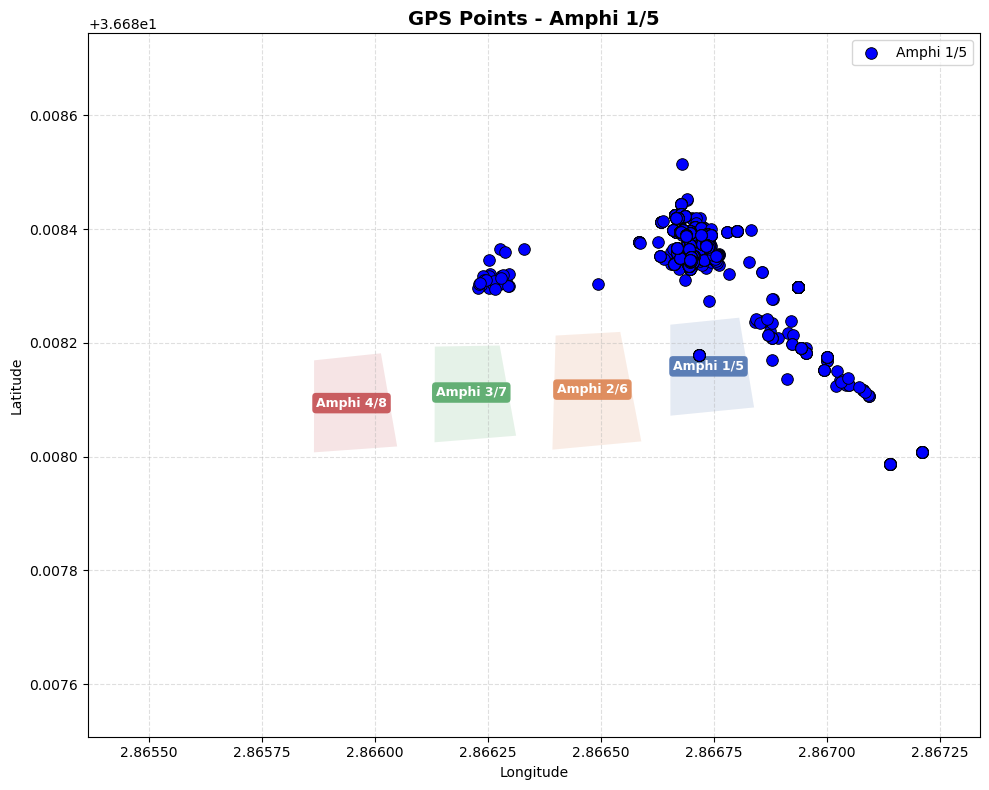

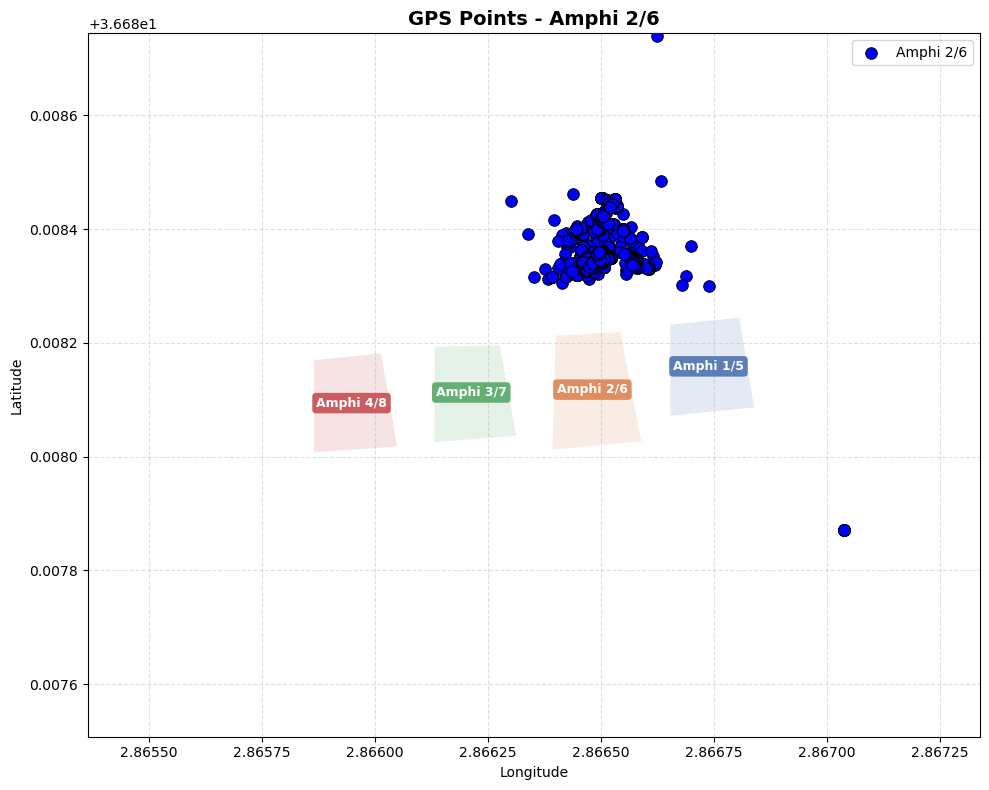

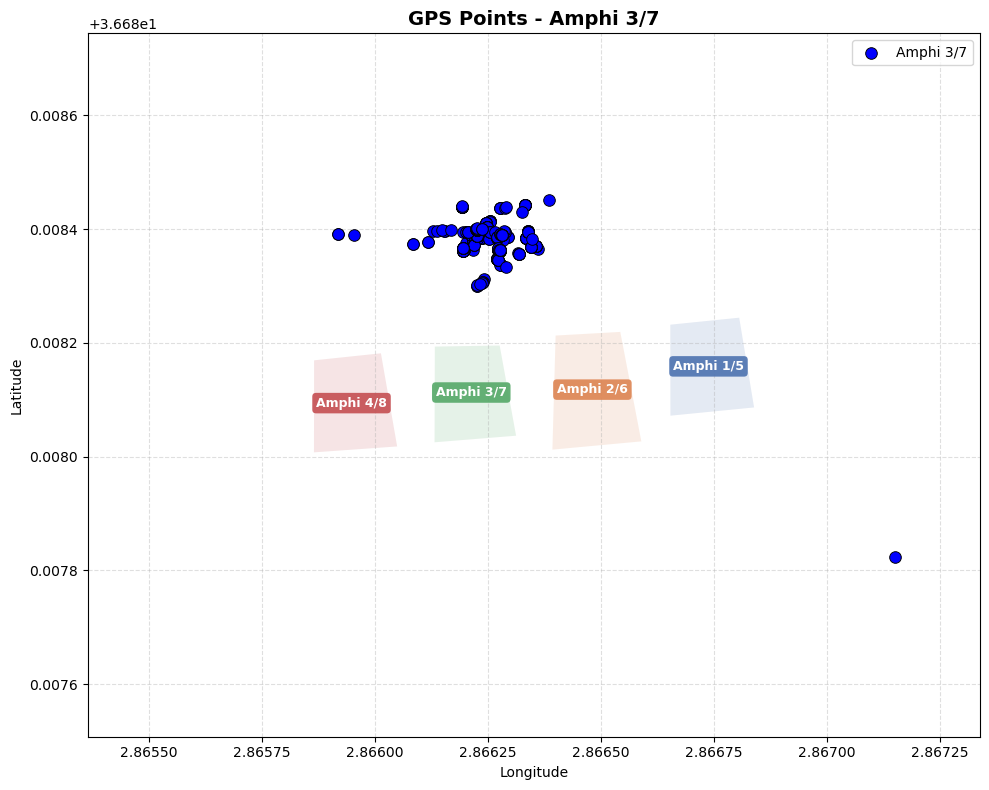

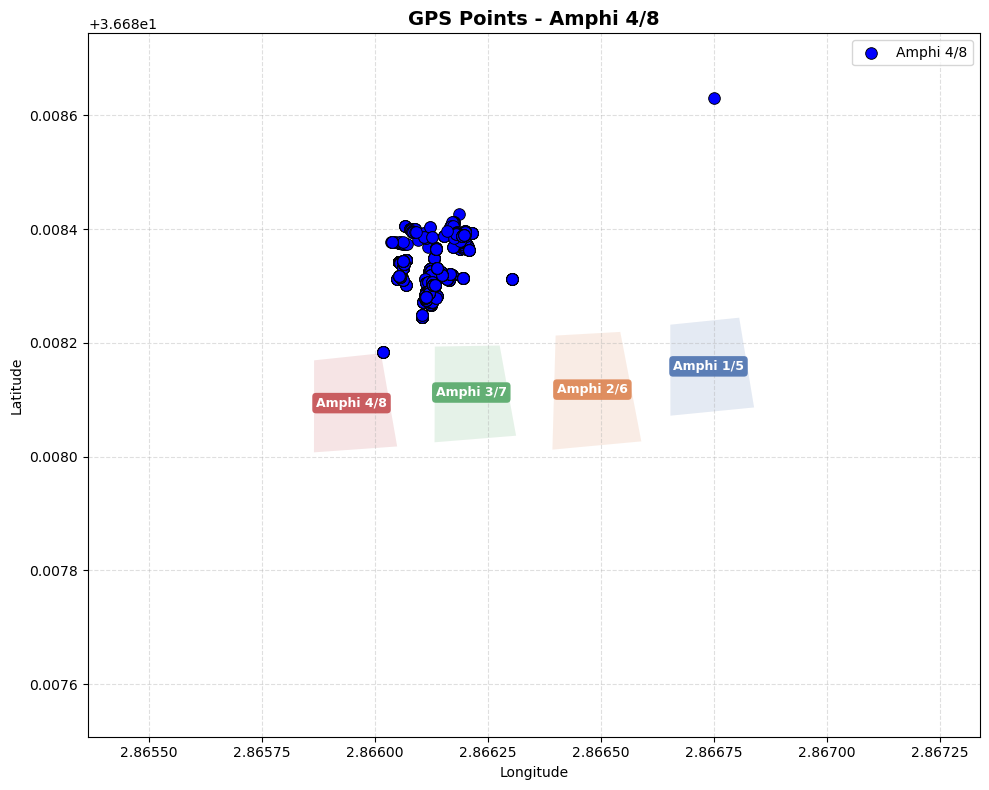

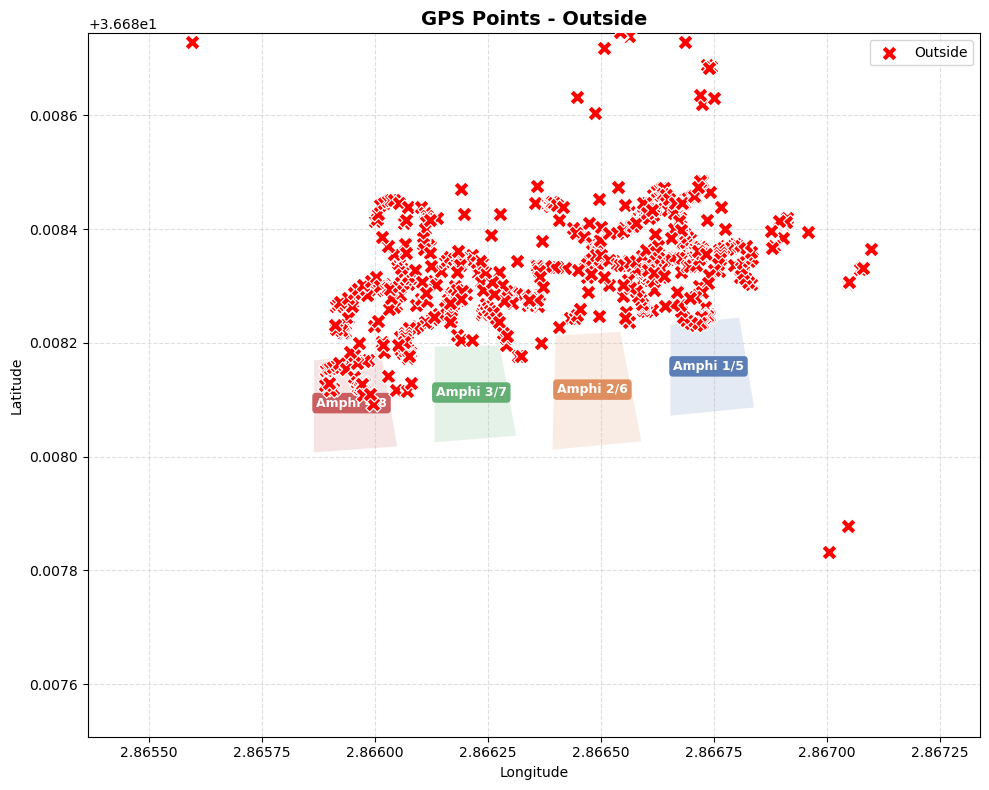

In [16]:
groups = [
    "Amphi 1/5",
    "Amphi 2/6",
    "Amphi 3/7",
    "Amphi 4/8",
    "Outside"
]

for g in groups:
    plot_amphi_group(df, g)

In [17]:
valid_amphis = {f"Amphi {i}" for i in range(1, 9)}

df['amphitheatre'] = df['amphitheatre'].apply(
    lambda x: x.strip() if isinstance(x, str) else x
)

df['amphitheatre'] = df['amphitheatre'].apply(
    lambda x: x if x in valid_amphis else "Outside"
)

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

def plot_single_amphi(df, amphi_name):
    fig, ax = plt.subplots(figsize=(10, 8))

    # =========================
    # 1. Draw all polygons
    # =========================
    patches = []
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    for (name, corners), color in zip(amphi_corners.items(), colors):
        xy = np.array([(lon, lat) for lat, lon in corners])
        poly = Polygon(xy, closed=True)
        patches.append(poly)

        cx, cy = xy[:, 0].mean(), xy[:, 1].mean()
        ax.text(
            cx, cy, name,
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc=color, ec='none', alpha=0.9)
        )

    ax.add_collection(PatchCollection(patches, facecolors=colors, alpha=0.15, zorder=1))

    # =========================
    # 2. Filter ONLY this amphi
    # =========================
    subset = df[df['amphitheatre'] == amphi_name]

    sns.scatterplot(
        data=subset,
        x='longitude_mean',
        y='latitude_mean',
        color='#1f77b4',
        edgecolor='black',
        s=70,
        alpha=0.85,
        ax=ax,
        label=amphi_name,
        zorder=3
    )

    # =========================
    # 3. Formatting
    # =========================
    ax.set_title(f"GPS Points - {amphi_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linestyle='--', alpha=0.4)

    # same fixed bounds
    all_lats = [c[0] for corners in amphi_corners.values() for c in corners]
    all_lons = [c[1] for corners in amphi_corners.values() for c in corners]
    ax.set_xlim(min(all_lons) - 0.0005, max(all_lons) + 0.0005)
    ax.set_ylim(min(all_lats) - 0.0005, max(all_lats) + 0.0005)

    ax.legend()
    plt.tight_layout()
    plt.show()

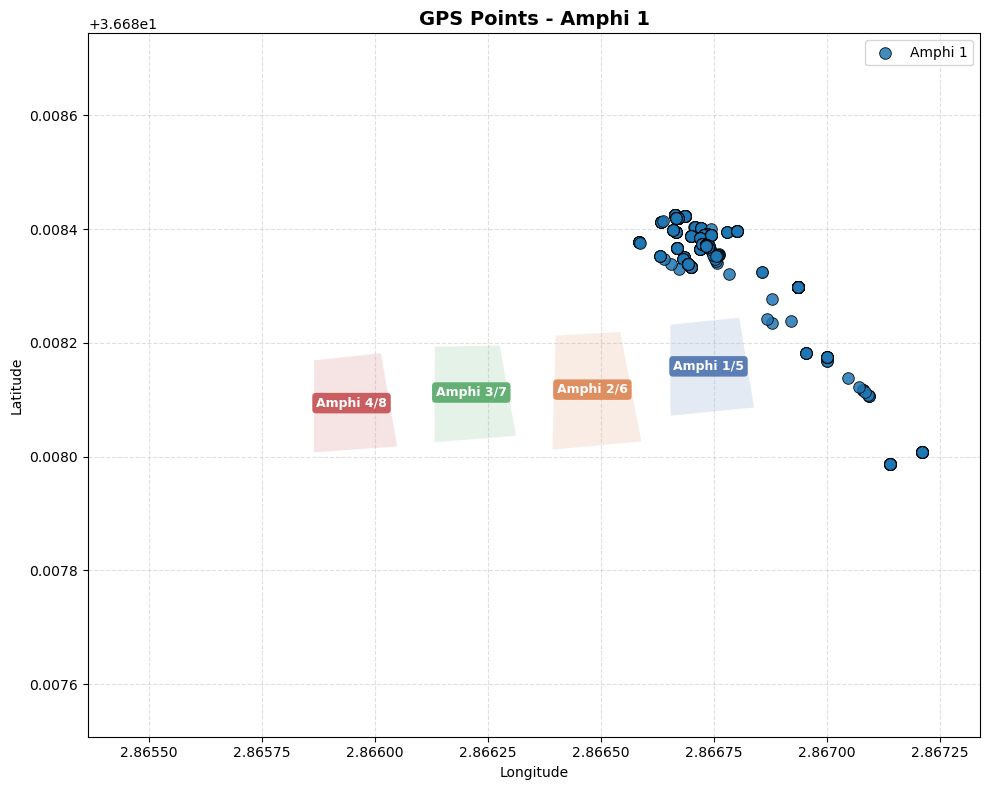

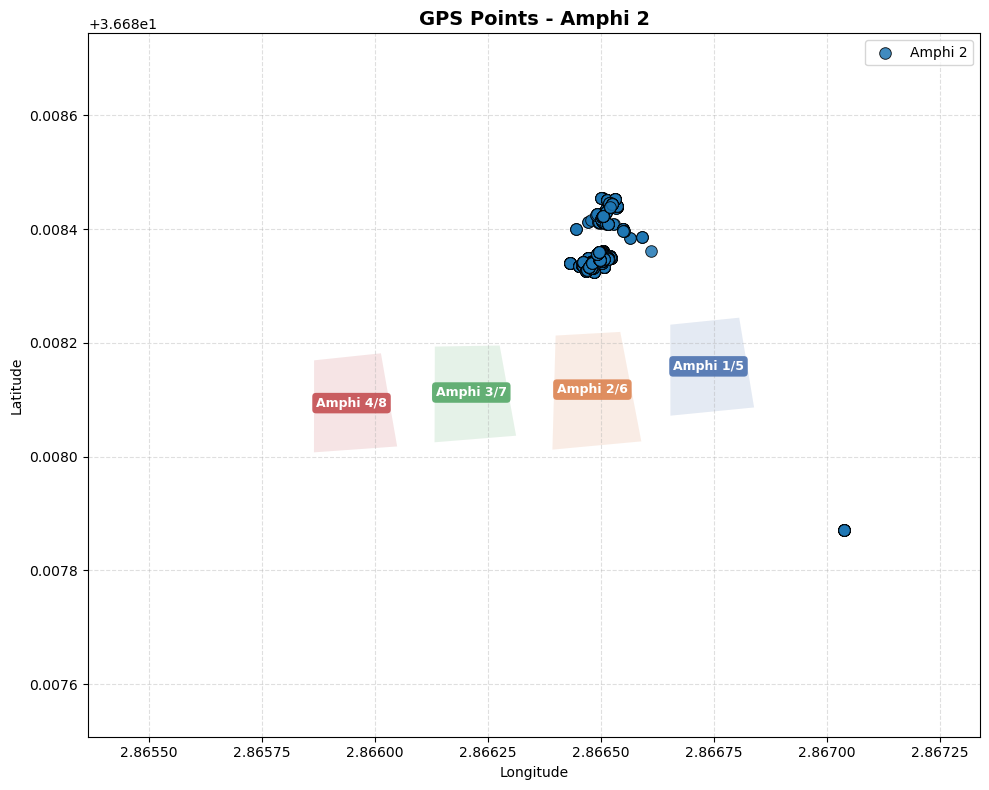

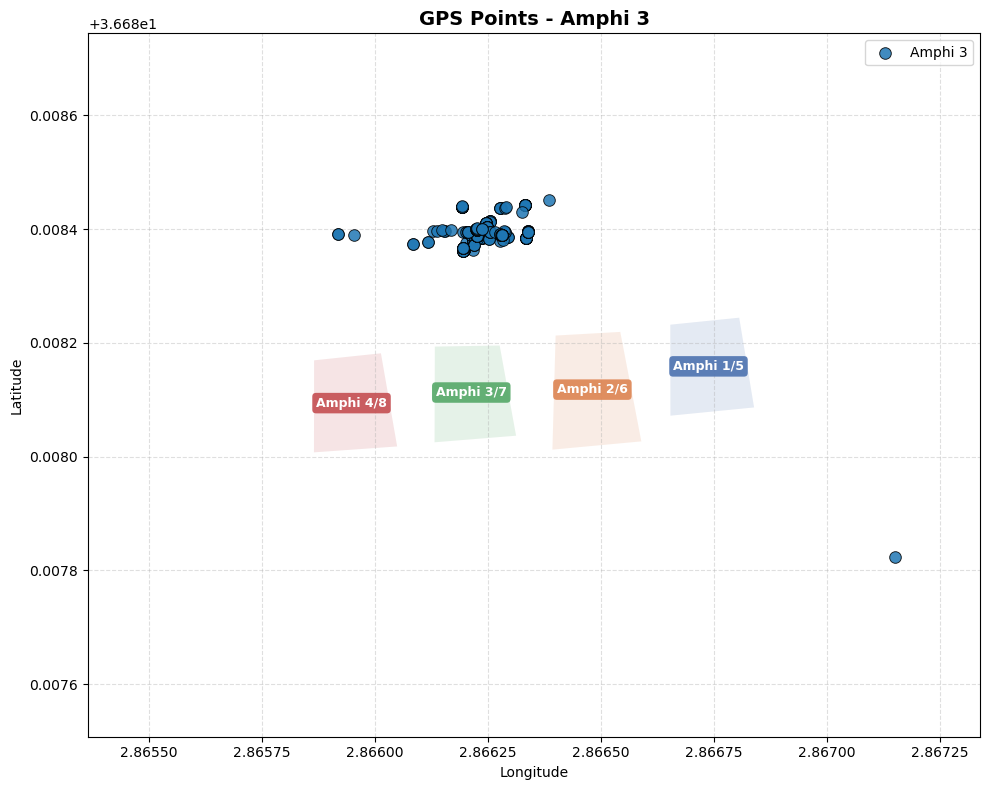

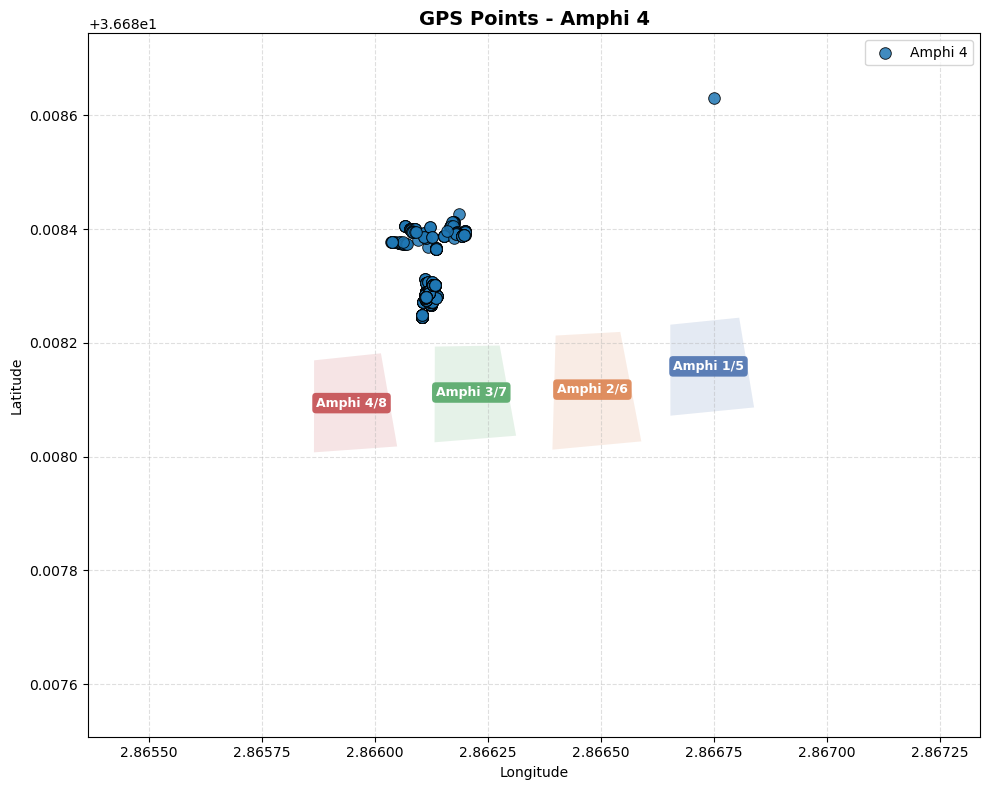

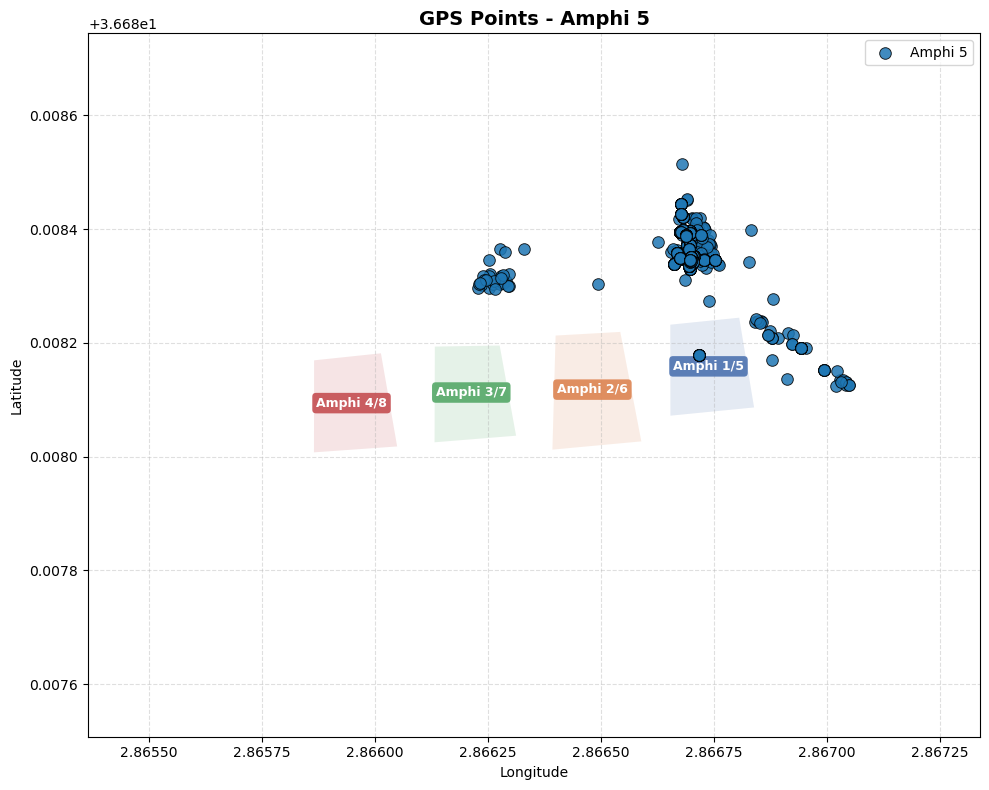

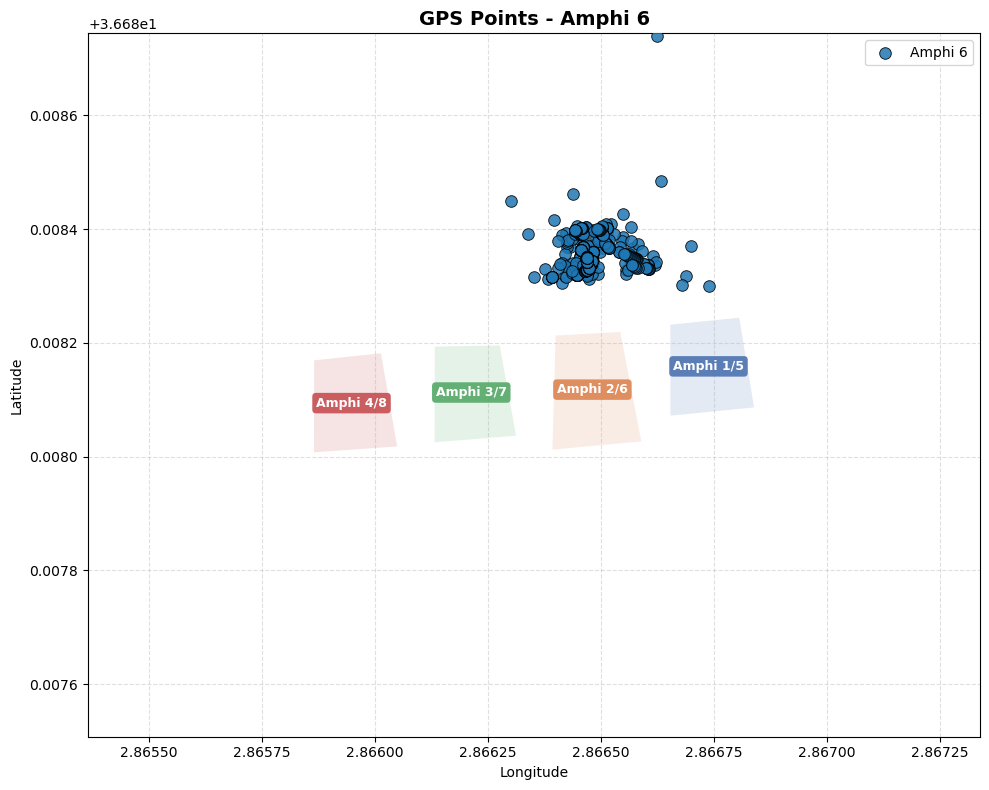

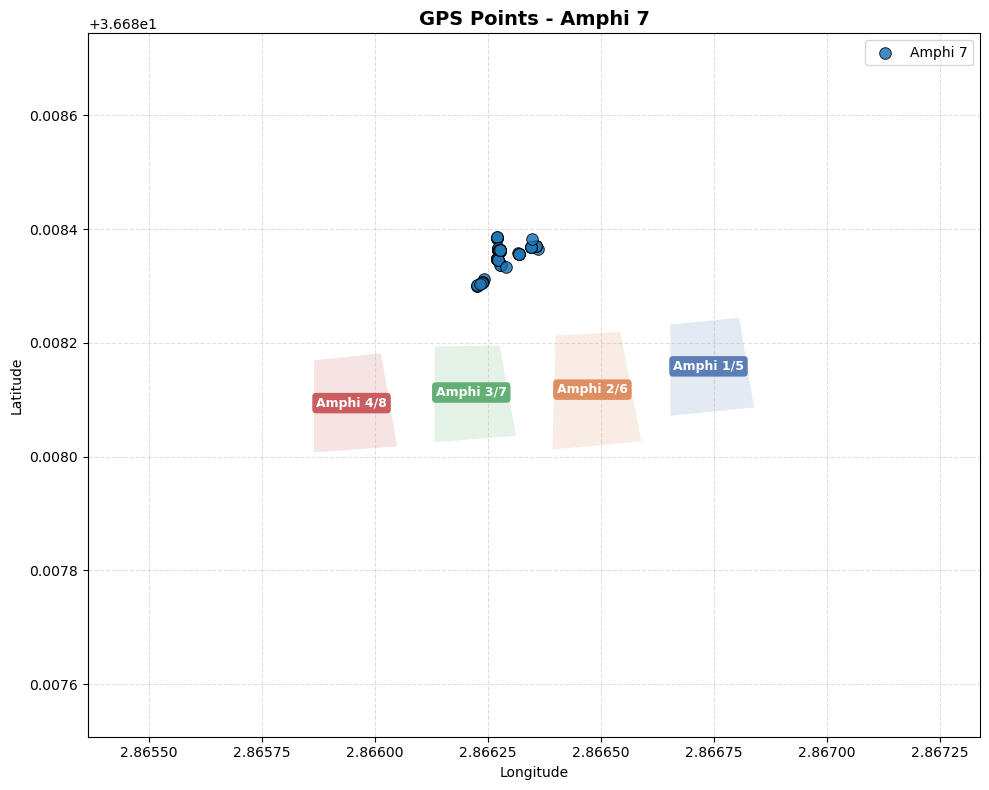

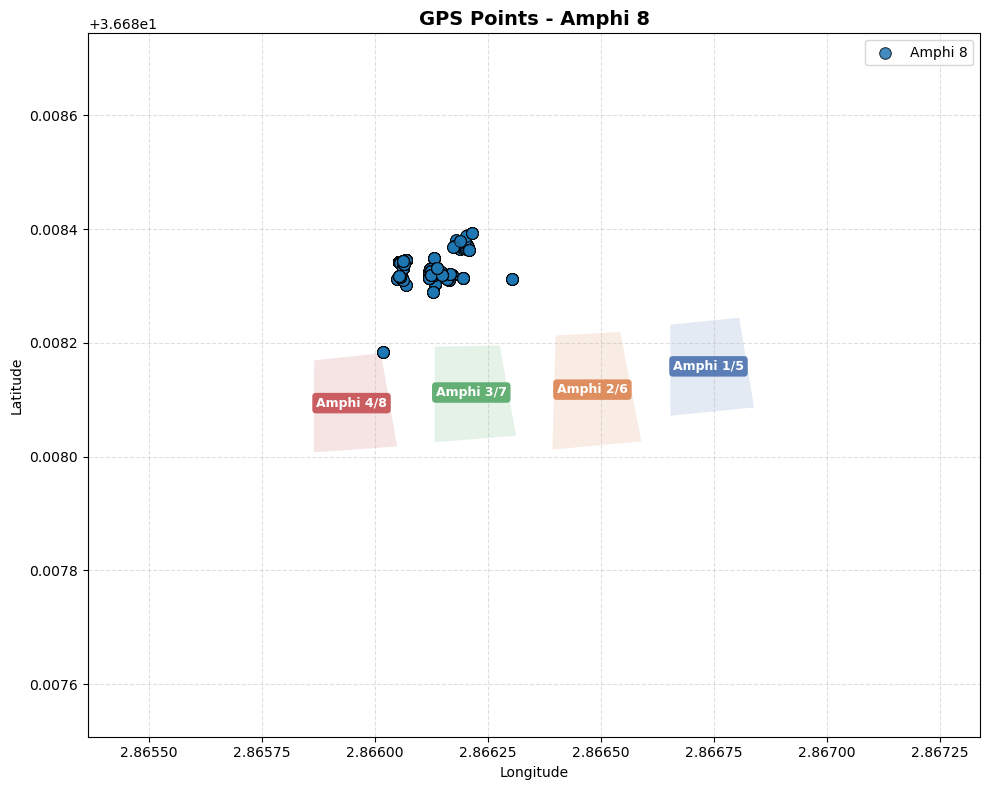

In [19]:
for i in range(1, 9):
    plot_single_amphi(df, f"Amphi {i}")